In [1]:
import collections
from modules.utils import plt_utils, log_utils, samp_utils, train_utils
from modules import types, configs, environments

## Settings

In [ ]:
DATASET_TYPE: types.DatasetTypes = "BGL" # "BGL" | "Liberty" | "Thunderbird" | "test"(based BGL)
SAMPLING_TYPE: types.SamplingTypes = "our" # "our" | "logllm"
SLIDING_WIN_TYPE: types.SlidingWindowTypes = "count" # "count" | "time"

## Init

In [3]:
work_config = configs.WORK_CONFIG_MAP[DATASET_TYPE]
ldfh = log_utils.LogDataFrameHelper()

## Log Embed Model Training Data Oversampling

Building semantic logs:   0%|          | 0/5000 [00:00<?, ?it/s]

Building semantic logs: 100%|██████████| 5000/5000 [00:00<00:00, 9859.10it/s]


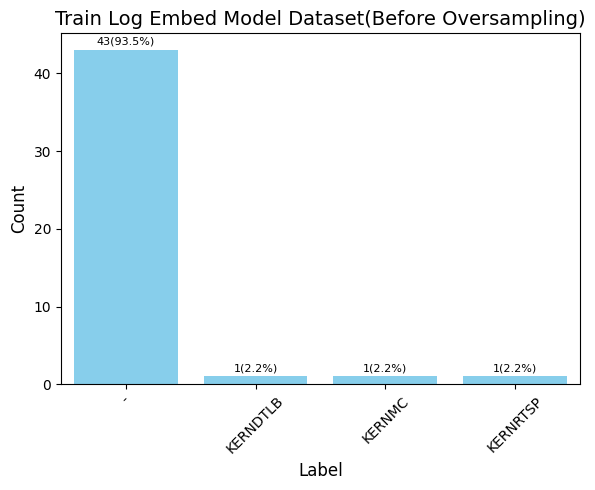

最大類別數量 43 筆
已過採樣類別 'KERNDTLB' : 新增 14 筆
已過採樣類別 'KERNMC' : 新增 14 筆
已過採樣類別 'KERNRTSP' : 新增 14 筆


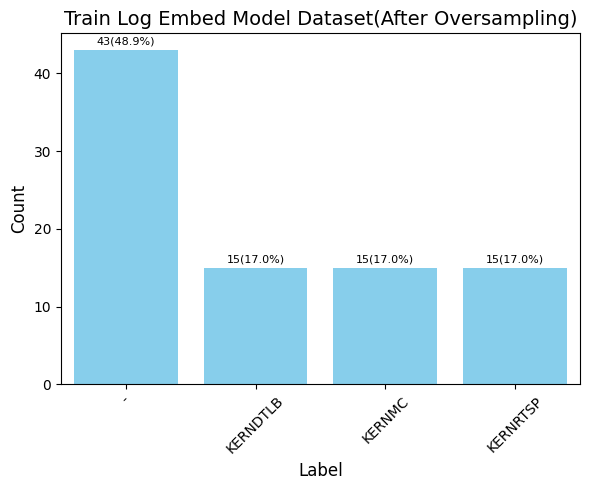

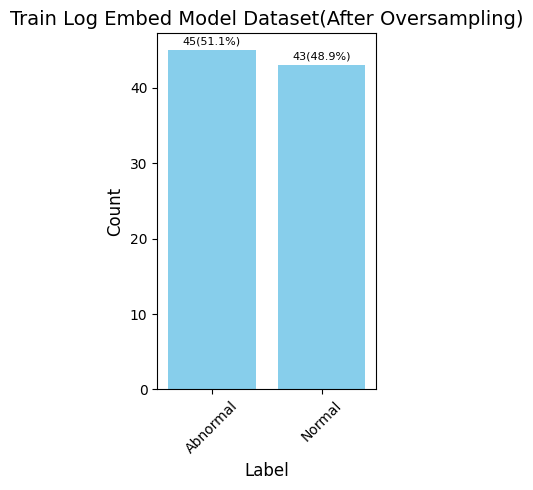

In [4]:
# Build structured logs
struct_logs_df = ldfh.build_struct_logs(
    log_path=work_config.dataset_config.path,
    log_format=work_config.dataset_config.fromat,
    start_line=work_config.dataset_config.start_line,
    end_line=work_config.dataset_config.end_line,
)

# Build semantic logs
logs_df = ldfh.build_semantic_logs(
    struct_logs_df=struct_logs_df,
    feature_columns=work_config.dataset_config.feat_columns,
    log_regex_replace_func=log_utils.log_regex_replace,
)

# Split training and testing logs
sampling_fn = samp_utils.train_test_sampling if SAMPLING_TYPE == "our" else samp_utils.logllm_train_test_sampling
train_logs_df, test_logs_df = sampling_fn(df=logs_df, train_ratio=environments.TRAIN_RATIO)

# Build unique logs
train_unique_logs_df = train_logs_df.drop_duplicates(subset=["log", "label"], inplace=False)
train_unique_logs, train_unique_logs_labels = train_unique_logs_df["log"].tolist(), train_unique_logs_df["label"].tolist()
plt_utils.draw_label_distribution(train_unique_logs_labels, title="Train Log Embed Model Dataset(Before Oversampling)")

# Oversamping
oversamp_beta = 1 / (len(set(train_unique_logs_labels)) - 1)
train_logs_oversamp, train_labels_oversamp = samp_utils.minority_oversampling(
    x=train_unique_logs, y=train_unique_logs_labels, beta=oversamp_beta,
)
plt_utils.draw_label_distribution(train_labels_oversamp, title="Train Log Embed Model Dataset(After Oversampling)")

# Binary labels
train_binary_labels = ["Normal" if x == "-" else "Abnormal" for x in train_labels_oversamp]
plt_utils.draw_label_distribution(train_binary_labels, title="Train Log Embed Model Dataset(After Oversampling)")

## Anomaly Detection LLM Training Data Oversampling

/home/wtlee4070s/chiaming/smart-om-agent/modules/utils/log_utils.py:112: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
Building train adllm wins: 100%|██████████| 41/41 [00:00<00:00, 15037.29it/s]


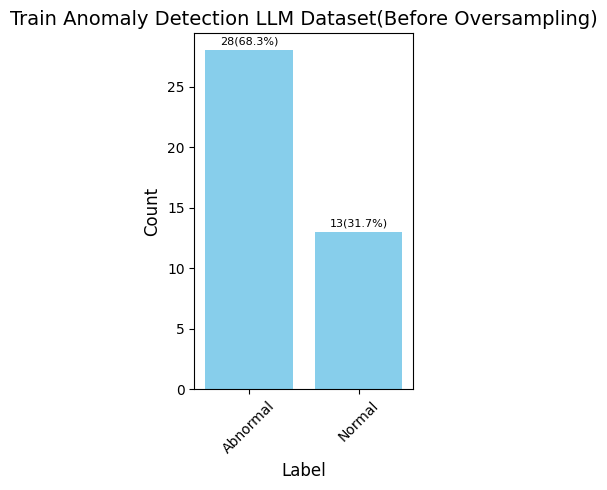

最大類別數量 28 筆
已過採樣類別 '0' : 新增 15 筆


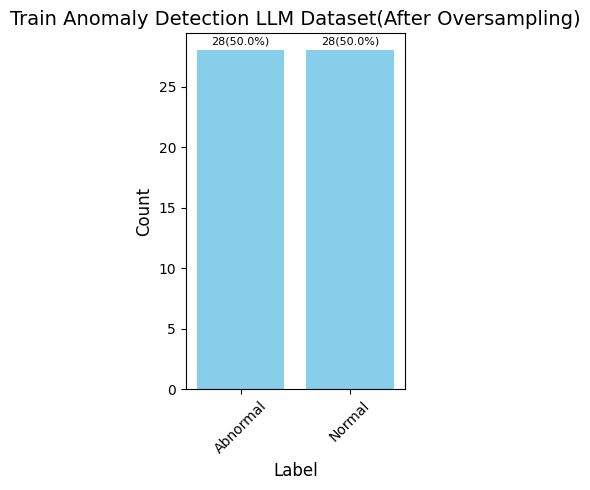

In [5]:
# Sliding log windows
build_wins_fn = ldfh.build_count_wins if SLIDING_WIN_TYPE == "count" else ldfh.build_time_wins
train_wins_df = build_wins_fn(df=train_logs_df)
train_wins_df = ldfh.build_train_adllm_wins(wins_df=train_wins_df, log_feature_vector_map=collections.defaultdict(float))

# Input and output cases
train_wins, train_wins_label = train_utils.parse_train_adllm_wins_df_to_train_case(train_wins_df)
train_binary_labels = ["Normal" if x == 0 else "Abnormal" for x in train_wins_label]
plt_utils.draw_label_distribution(train_binary_labels, title="Train Anomaly Detection LLM Dataset(Before Oversampling)")
    
# Oversampling
oversamp_beta = 1
train_wins_oversamp, train_labels_oversamp = samp_utils.minority_oversampling(
    x=train_wins, y=train_wins_label, beta=oversamp_beta, 
)

train_binary_labels = ["Normal" if x == 0 else "Abnormal" for x in train_labels_oversamp]
plt_utils.draw_label_distribution(train_binary_labels, title="Train Anomaly Detection LLM Dataset(After Oversampling)")